# Filtering Problem

Suposse the state $X_t \in \R^n$ at time t of a system is given by a stocvhastic differential equation
$$ dX_t = b(t,X_t)dt + \sigma(t,X_t)dU_t, \quad X(0) = X_0, $$
where $b:\R^{n+1} \to \R^n$, $\sigma:\R^{n+1} \to \R^{n\times p}$ and $U_t$ is a p-dimensional Browniam motion. 

However, what we measure as a result of the disturbances is a state $Z_t \in \R^m$ satisfying another stocvhastic differential equation
$$ dZ_t = c(t,X_t)dt + \gamma(t,X_t)dV_t,  \quad Z(0) = Z_0,$$
where $c:\R^{n+1} \to \R^m$, $\gamma:\R^{n+1} \to \R^{m\times q}$ and $V_t$ is a q-dimensional Browniam motion. 

In this situation, the filtering problem consists of, given the observations $Z_s$ for $0 \leq s \leq t$, we want to find the best aproximation of $X_t$ at time t $\hat{X}_t$ in the following sense:
$$ \begin{cases}
    \hat{X}_t(\cdot) \text{ is } \mathcal{C_t} \text { measurable, where } \mathcal{C_t} \text{ is the } \sigma\text{-algebra generated by } \{ Z_s, 0 \leq s \leq t\} \\
    E\left[ \left| X_t - \hat{X}_t \right|^2 \right] =  \inf\left\{ E\left[ \left| X_t - Y \right|^2 \right], \; Y \in L^2(P), \; Y \text{ is }\mathcal{C}_t \text{ measurable} \right\} \; \forall t >0
\end{cases}$$
where we denote by $(\Omega, \mathcal{F}, P)$ the probability space where the Browniam motion $(U_t, V_t)$


## The 1-dimensional Linear Filtering Problem

**Theorem: The 1-dimensional Kalman-Bucy filter**

*The solution $\widehat{X}_t$ of the 1-dimensional linear filtering problem*

$$
\begin{aligned}
&\text{(linear system)} & dX_t &= F(t)X_t dt + C(t)dU_t; \quad & F(t), C(t) &\in \mathbf{R}   \\
&\text{(linear observations)} & dZ_t &= G(t)X_t dt + D(t)dV_t; \quad & G(t), D(t) &\in \mathbf{R} \\
\end{aligned}
$$

*(with the conditions: F,C,G,D are bounded on bounded intervals with D away from zero, $Z_0 = 0$ and $X_0$ is independent of $(U_t,V_t)$ and is normally distributed) satisfies the stochastic differential equation*

$$d\widehat{X}_t = \left( F(t) - \frac{G^2(t)S(t)}{D^2(t)} \right) \widehat{X}_t dt + \frac{G(t)S(t)}{D^2(t)} dZ_t ; \quad \widehat{X}_0 = E[X_0] $$

*where* $S(t) = E[(X_t - \widehat{X}_t)^2]$ *satisfies the (deterministic) Riccati equation*

$$\frac{dS}{dt} = 2F(t)S(t) - \frac{G^2(t)}{D^2(t)}S^2(t) + C^2(t), \quad S(0) = E[(X_0 - E[X_0])^2]. $$

### Application to the Ornstein-Uhlenbeck process

Imagine we are tracking an autonomous underwater vehicle (or a particle).

The Dynamics (The System): The vehicle experiences a frictional force proportional to its position that tends to return it to its starting point (mean reversion), but it also undergoes random impacts from underwater currents.
$$dX_t = -\lambda X_t dt + \sigma dU_t,$$
where $\lambda > 0$ is the coefficient of friction or rate of return to the mean and $\sigma > 0$ is the magnitude of the noise.

The Measurement (The Observations): We have an acoustic sonar sensor that measures the vehicle’s position, but the sensor has constant white noise in the background due to the ocean environment.
$$dZ_t = X_t dt + \gamma dV_t$$
where $\gamma > 0$ is the magnitude of the sensor`s noise.

We assume that we have no idea where exactly the vehicle started, but we suppose that it began at an estimated average position $\hat{X}_0 = 0$ with a large initial uncertainty $S_0$

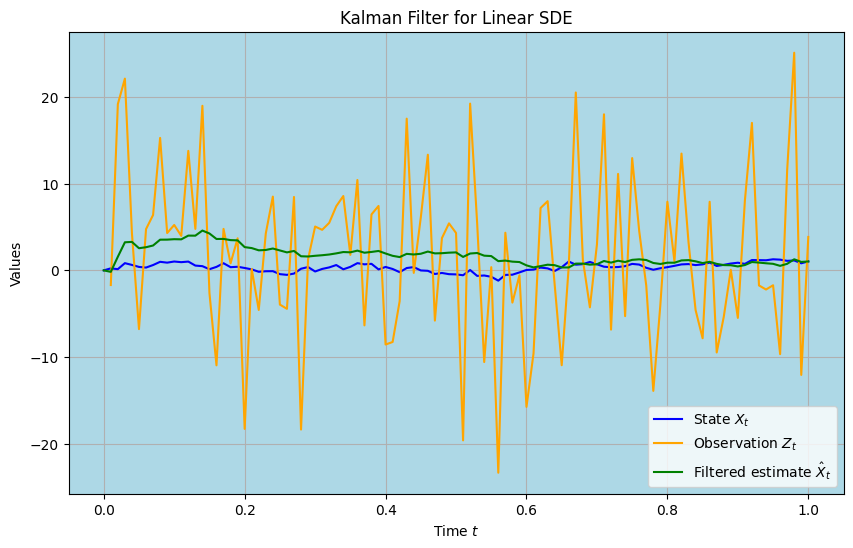

Mean squared error: 3.1848131628989442


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import BarycentricInterpolator
from scipy.interpolate import interp1d

# Euler-Maruyama method for simulating SDEs
def euler_maruyama(b, sigma, T, Z, N, W = None):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    X = np.zeros(N + 1)
    X[0] = Z

    if W is None:
        W = np.zeros(N + 1)
        W[1:] = np.random.normal(0, np.sqrt(dt), N)
        W = np.cumsum(W)
    
    for n in range(N):
        tn = t[n]
        Xn = X[n]
        dW = W[n+1] - W[n]
        X[n+1] = Xn + b(tn, Xn) * dt + sigma(tn, Xn) * dW
    return t, X

# The deterministic Riccati equation
def Riccati(t,S, F, C, G, D):
    return 2*F(t)*S - (G(t)*S/D(t))**2 + C(t)**2

# Data of the problem
lambda_ = 1.0
F = lambda t: -lambda_
sigma_ = 3.0
C = lambda t: sigma_
G = lambda t: 1.0
gamma_ = 1.0
D = lambda t: gamma_
X_0 = 0.0
S_0 = 10.0
T = 1.0

# Simualte the state X_t
t,X = euler_maruyama(lambda t,x: F(t)*x, lambda t,x: C(t), T, X_0, 100)

# Simulate the observation Z_t
interpolator = interp1d(t, X, kind='linear')
_,Z = euler_maruyama(lambda t,x: G(t)*interpolator(t), lambda t,x: D(t), T, 0.0, 100)

# Calculate the solution of the Riccati equation
sol = solve_ivp(lambda t,S: Riccati(t, S, F, C, G, D), [0, T], [S_0], t_eval=t)
S = sol.y[0]
S = interp1d(t, S, kind='linear')

# The Kalman filter equations
b = lambda t,x: (F(t) - (G(t)**2 * S(t) / (D(t)**2))) * x
sigma = lambda t,x: G(t)*S(t)/(D(t)**2)
_,hatX = euler_maruyama(b, sigma, T, X_0, 100, W=Z)

plt.figure(figsize=(10, 6))
plt.plot(t, X, label='State $X_t$', color='blue')
dt = t[1] - t[0]
plt.plot(t[1:], np.diff(Z)/dt, label='Observation $Z_t$', color='orange')
plt.plot(t, hatX, label='Filtered estimate $\hat{X}_t$', color='green')
plt.title('Kalman Filter for Linear SDE')
plt.xlabel('Time $t$')
plt.ylabel('Values')
plt.legend()
plt.grid()
plt.gca().set_facecolor('lightblue')
plt.show()

error = np.mean((X - hatX)**2)
print(f"Mean squared error: {error}")

## The Multidimensional Linear Filtering Problem

**Theorem: The Multi-Dimensional Kalman-Bucy Filter.**

The solution $\widehat{X}_t$ of the multi-dimensional linear filtering problem

$$\begin{align}
\text{(linear system)} \quad & dX_t = F(t)X_t dt + C(t)dU_t; \quad & F(t) \in \mathbf{R}^{n \times n}, C(t) \in \mathbf{R}^{n \times p} \\
\text{(linear observations)} \quad & dZ_t = G(t)X_t dt + D(t)dV_t; \quad & G(t) \in \mathbf{R}^{m \times n}, D(t) \in \mathbf{R}^{m \times r}
\end{align}$$

satisfies the stochastic differential equation

$$d\widehat{X}_t = \left(F - SG^T(DD^T)^{-1}G \right)\widehat{X}_t dt + SG^T(DD^T)^{-1}dZ_t ; \quad \widehat{X}_0 = E[X_0] $$

where $S(t) := E[(X_t - \widehat{X}_t)(X_t - \widehat{X}_t)^T] \in \mathbf{R}^{n \times n}$ satisfies the matrix Riccati equation

$$\begin{align}
\frac{dS}{dt} &= FS + SF^T - SG^T(DD^T)^{-1}GS + CC^T ; \\
S(0) &= E[(X_0 - E[X_0])(X_0 - E[X_0])^T]. \tag{6.3.4}
\end{align}$$

The condition on $D(t) \in \mathbf{R}^{m \times r}$ is now that $D(t)D(t)^T$ is invertible for all $t$ and that $(D(t)D(t)^T)^{-1}$ is bounded on every bounded $t$-interval.

## Mathematical Formulation of the 3D Missile Tracking Problem

We aim to estimate the real-time trajectory of a ballistic missile flying in a 3D space using noisy radar measurements. We model this as a continuous-time linear filtering problem (Kalman-Bucy filter).

1. The State Vector
The state of the missile at time $t$ is described by a 6-dimensional vector containing its 3D position and 3D velocity:


$$X_t = \begin{bmatrix} x & y & z & v_x & v_y & v_z \end{bmatrix}^T \in \mathbb{R}^6$$

2. System Dynamics (The Physical Model)
The evolution of the missile is governed by the following Stochastic Differential Equation (SDE):


$$dX_t = (F X_t + u)dt + C dU_t$$


Where:

$F \in \mathbb{R}^{6 \times 6}$ is the state transition matrix that links velocity to the rate of change of position ($\frac{d\mathbf{p}}{dt} = \mathbf{v}$).

$u = \begin{bmatrix} 0 & 0 & 0 & 0 & 0 & -g \end{bmatrix}^T$ is a deterministic drift term accounting for Earth's gravity ($g \approx 9.81 \, \text{m/s}^2$).

$C \in \mathbb{R}^{6 \times 3}$ is the system noise matrix. We assume that wind turbulence only directly affects the velocity components (acceleration noise).

$dU_t$ represents the increments of a 3-dimensional standard Brownian motion modeling the unpredictable wind gusts.

3. Observation Dynamics (The Radar)
A ground-based radar continuously tracks the missile. However, the radar can only measure the 3D position (not the velocity), and its signal is corrupted by atmospheric and thermal white noise. We model the integrated observation process $Z_t \in \mathbb{R}^3$ as:


$$dZ_t = G X_t dt + D dV_t$$


Where:

$G \in \mathbb{R}^{3 \times 6}$ is the observation matrix that projects the 6D state space onto the 3D position space (extracting only $x, y, z$).

$D \in \mathbb{R}^{3 \times 3}$ is the observation noise matrix (sensor covariance), determined by the radar's inaccuracy ($\sigma_{radar}$).

$dV_t$ represents the increments of an independent 3-dimensional standard Brownian motion modeling the sensor noise.

Objective:
Given the continuous stream of noisy radar observations up to time $t$ (the filtration $\mathcal{G}_t$), we want to compute the optimal minimum mean square error (MMSE) estimate of the missile's true state, given by $\widehat{X}_t = E[X_t | \mathcal{G}_t]$, using the continuous multi-dimensional Kalman-Bucy filter.

Solving Riccati Equation...
Simulating trajectory and filter...


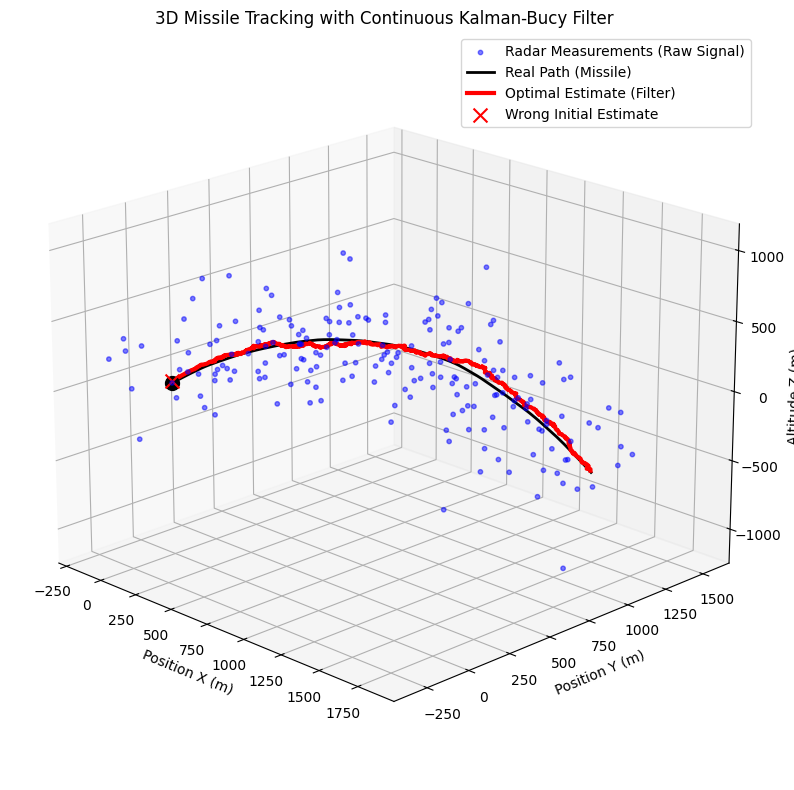

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ==========================================
# 1. PHYSICAL MODEL PARAMETERS
# ==========================================
T = 20.0          # Total flight time (seconds)
N_steps = 1000    # Number of integration steps
dt = T / N_steps
t = np.linspace(0, T, N_steps + 1)

# Continuous system matrices dX = (F*X + u)dt + C*dU
# State: [x, y, z, vx, vy, vz]
F = np.zeros((6, 6))
F[0, 3] = 1.0  # dx/dt = vx
F[1, 4] = 1.0  # dy/dt = vy
F[2, 5] = 1.0  # dz/dt = vz

# Gravity (deterministic term)
u = np.array([0, 0, 0, 0, 0, -9.81])

# System noise (wind turbulence affects velocity only)
sigma_wind = 5.0
C = np.zeros((6, 3))
C[3:, :] = sigma_wind * np.eye(3)

# Observation matrices dZ = G*X dt + D*dV
# Radar measures positions (x, y, z) only, not velocities
G = np.zeros((3, 6))
G[0, 0] = 1.0
G[1, 1] = 1.0
G[2, 2] = 1.0

# Radar sensor noise
sigma_radar = 30.0
D = sigma_radar * np.eye(3)
D_inv_sq = np.linalg.inv(D @ D.T) # (D * D^T)^-1

# Initial conditions
X_0 = np.array([0.0, 0.0, 0.0, 100.0, 50.0, 100.0]) # Launch from origin
X_hat_0 = np.array([10.0, -10.0, 20.0, 80.0, 60.0, 90.0]) # Wrong initial estimate
S_0 = 100.0 * np.eye(6) # Large initial uncertainty

# ==========================================
# 2. MATRIX RICCATI EQUATION
# ==========================================
def riccati_ode(t, S_flat):
    # Rebuild 6x6 matrix
    S = S_flat.reshape((6, 6))
    
    # Riccati equation: dS/dt = F*S + S*F^T - S*G^T*(D*D^T)^-1*G*S + C*C^T
    term1 = F @ S
    term2 = S @ F.T
    term3 = S @ G.T @ D_inv_sq @ G @ S
    term4 = C @ C.T
    
    dSdt = term1 + term2 - term3 + term4
    return dSdt.flatten() # Flatten for solve_ivp

# Solve Riccati forward in time
print("Solving Riccati Equation...")
sol = solve_ivp(riccati_ode, [0, T], S_0.flatten(), t_eval=t)

# Create interpolator for covariance matrix S(t)
# We use linear interpolation component by component
S_t = interp1d(t, sol.y, axis=1, kind='linear')

# ==========================================
# 3. STOCHASTIC SIMULATION (Euler-Maruyama 3D)
# ==========================================
print("Simulating trajectory and filter...")
X = np.zeros((N_steps + 1, 6))
Z_dot = np.zeros((N_steps + 1, 3)) # Derivative of Z (raw radar signal)
X_hat = np.zeros((N_steps + 1, 6))

X[0] = X_0
X_hat[0] = X_hat_0

for n in range(N_steps):
    tn = t[n]
    
    # Independent Brownian noises
    dU = np.sqrt(dt) * np.random.randn(3) # 3D turbulence
    dV = np.sqrt(dt) * np.random.randn(3) # 3D Radar noise
    
    # 1. Real State Propagation (The missile in reality)
    dX = (F @ X[n] + u) * dt + C @ dU
    X[n+1] = X[n] + dX
    
    # 2. Raw Radar Signal (pseudo-continuous dZ/dt for visualization)
    # dZ = G*X*dt + D*dV  --> Perceived signal = dZ/dt
    Z_dot[n+1] = G @ X[n] + (D @ dV) / dt
    dZ = Z_dot[n+1] * dt
    
    # 3. Optimal Filter (Kalman-Bucy)
    S_actual = S_t(tn).reshape((6, 6))
    
    # Kalman Gain: K(t) = S(t) * G^T * (D*D^T)^-1
    K = S_actual @ G.T @ D_inv_sq
    
    # Innovation: dN = dZ - G * X_hat * dt
    dN = dZ - (G @ X_hat[n]) * dt
    
    # Estimate propagation
    dX_hat = (F @ X_hat[n] + u) * dt + K @ dN
    X_hat[n+1] = X_hat[n] + dX_hat

# ==========================================
# 4. 3D VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract position coordinates
x_real, y_real, z_real = X[:, 0], X[:, 1], X[:, 2]
x_radar, y_radar, z_radar = Z_dot[:, 0], Z_dot[:, 1], Z_dot[:, 2]
x_filt, y_filt, z_filt = X_hat[:, 0], X_hat[:, 1], X_hat[:, 2]

# Plot Radar (Scattered points with massive noise)
ax.scatter(x_radar[::5], y_radar[::5], z_radar[::5], 
           c='blue', s=10, alpha=0.5, label='Radar Measurements (Raw Signal)')

# Plot Real Path
ax.plot(x_real, y_real, z_real, 
        color='black', linewidth=2, label='Real Path (Missile)')

# Plot Filtered Path
ax.plot(x_filt, y_filt, z_filt, 
        color='red', linewidth=3, linestyle='-', label='Optimal Estimate (Filter)')

# Starting point
ax.scatter(X_0[0], X_0[1], X_0[2], color='black', s=100, marker='o')
ax.scatter(X_hat_0[0], X_hat_0[1], X_hat_0[2], color='red', s=100, marker='x', label='Wrong Initial Estimate')

ax.set_title('3D Missile Tracking with Continuous Kalman-Bucy Filter')
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Y (m)')
ax.set_zlabel('Altitude Z (m)')
ax.legend()

# Adjust viewing angle
ax.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.show()

## Numerical Solutions for General Filtering Problems: Particle Filters

The Kalman-Bucy filter is exact only when the system and observation equations are linear and the noise is Gaussian. In the general (non-linear) case the optimal estimate is the conditional expectation
$$\widehat{X}_t = E[X_t \mid \mathcal{C}_t] = \int_{\mathbb{R}^n} x \, \pi_t(x) \, dx,$$
where $\pi_t(x)$ is the conditional probability density of $X_t$ given the observations $\{Z_s,\ 0 \le s \le t\}$. This density evolves according to the Zakai / Kushner-Stratonovich stochastic PDE, which is infinite-dimensional: in general $\pi_t$ cannot be described by a finite set of parameters (such as a mean and a covariance), and for highly non-linear or non-Gaussian systems it has no closed-form solution.

**Sequential Monte Carlo (SMC)** methods, also called *particle filters*, approximate $\pi_t$ by a weighted empirical measure of $N$ random samples ("particles"):
$$\pi_t(x) \approx \sum_{i=1}^{N} w_t^{(i)} \, \delta_{x_t^{(i)}}(x), \qquad \sum_{i=1}^{N} w_t^{(i)} = 1,$$
so that any expectation becomes a weighted sum, $E[\varphi(X_t) \mid \mathcal{C}_t] \approx \sum_{i} w_t^{(i)} \varphi\big(x_t^{(i)}\big)$. By the law of large numbers, this approximation converges to the true conditional expectation as $N \to \infty$.

**The SIR (Sampling Importance Resampling) algorithm.** Let the time be discretized as $t_k = k\,\Delta t$, and let $z_k$ denote the observation available at time $t_k$. Initialize $x_0^{(i)} \sim \pi_0$ and $w_0^{(i)} = 1/N$. For each step $k = 1, 2, \dots$:

1. **Prediction (numerical integration of the system SDE).** Propagate every particle independently with a numerical scheme such as Euler-Maruyama:
$$x_k^{(i)} = x_{k-1}^{(i)} + b\big(t_{k-1}, x_{k-1}^{(i)}\big)\Delta t + \sigma\big(t_{k-1}, x_{k-1}^{(i)}\big)\sqrt{\Delta t}\, \xi_k^{(i)}, \qquad \xi_k^{(i)} \sim \mathcal{N}(0, I_p).$$
This draws a sample from the prior (transition) density $p\big(x_k \mid x_{k-1}^{(i)}\big)$.

2. **Weight update (observation likelihood).** Re-weight each particle by how well it explains the new measurement:
$$\tilde{w}_k^{(i)} = w_{k-1}^{(i)} \, p\big(z_k \mid x_k^{(i)}\big), \qquad w_k^{(i)} = \frac{\tilde{w}_k^{(i)}}{\sum_{j=1}^{N} \tilde{w}_k^{(j)}}.$$
For Gaussian sensor noise with covariance $R$ this likelihood is $p(z_k \mid x_k^{(i)}) \propto \exp\!\Big(-\tfrac{1}{2}\big(z_k - h(x_k^{(i)})\big)^T R^{-1} \big(z_k - h(x_k^{(i)})\big)\Big)$.

3. **State estimation.** The approximate MMSE estimate is the weighted mean of the particle cloud:
$$\widehat{X}_k \approx \sum_{i=1}^{N} w_k^{(i)} \, x_k^{(i)}.$$

4. **Resampling.** After a few iterations, almost all the weight concentrates on a handful of particles (*particle degeneracy*). This is monitored with the effective sample size
$$N_{\text{eff}} = \frac{1}{\sum_{i=1}^{N} \big(w_k^{(i)}\big)^2}.$$
When $N_{\text{eff}}$ falls below a threshold (typically $N/2$), draw $N$ new particles from the current weighted set (with replacement, with probabilities $w_k^{(i)}$) and reset $w_k^{(i)} = 1/N$. Likely particles are duplicated and unlikely ones are discarded.

### Real-World Application: Monte Carlo Localization (MCL) in Autonomous Robotics

A mobile robot moves on a plane that contains $L$ landmarks at known positions $\ell_j = (a_j, b_j) \in \mathbb{R}^2$, $j = 1, \dots, L$. The robot does not know where it is, and must infer its pose from its control commands and from noisy LiDAR range readings. This is the *global localization* problem, and the posterior is typically multimodal, which a Kalman filter cannot represent.

**1. The hidden state.** The pose of the robot at time $t$ is a continuous 3-dimensional state
$$X_t = \begin{bmatrix} x_t & y_t & \theta_t \end{bmatrix}^T \in \mathbb{R}^2 \times [-\pi, \pi),$$
where $(x_t, y_t)$ is the 2D position and $\theta_t$ is the heading angle.

**2. Non-linear system dynamics.** The robot follows unicycle (differential-drive) kinematics driven by the commanded forward speed $v(t)$ and steering rate $\omega(t)$, perturbed by mechanical noise (wheel slip, actuator imprecision) modeled as Brownian motion:
$$dX_t = \underbrace{\begin{bmatrix} v(t)\cos\theta_t \\ v(t)\sin\theta_t \\ \omega(t) \end{bmatrix}}_{b(t, X_t)} dt \;+\; \underbrace{\begin{bmatrix} \sigma_v \cos\theta_t & 0 \\ \sigma_v \sin\theta_t & 0 \\ 0 & \sigma_\omega \end{bmatrix}}_{\sigma(X_t)} \begin{bmatrix} dU_t^{(1)} \\ dU_t^{(2)} \end{bmatrix},$$
where $U_t = (U_t^{(1)}, U_t^{(2)})$ is a 2-dimensional standard Brownian motion, $\sigma_v$ is the intensity of the velocity noise and $\sigma_\omega$ is the intensity of the steering noise. The drift $b$ and the diffusion coefficient $\sigma$ depend non-linearly on the heading $\theta_t$ through $\cos\theta_t$ and $\sin\theta_t$, so the system is *not* linear.

**3. Non-linear observation model.** A LiDAR sensor measures the distance from the robot to each landmark. In the notation of the filtering problem, the observation is
$$dZ_t = c(X_t)\,dt + \gamma\, dV_t, \qquad c(X_t) = \begin{bmatrix} \sqrt{(x_t - a_1)^2 + (y_t - b_1)^2} \\ \vdots \\ \sqrt{(x_t - a_L)^2 + (y_t - b_L)^2} \end{bmatrix} \in \mathbb{R}^L,$$
with $V_t$ an $L$-dimensional Brownian motion independent of $U_t$ and $\gamma = \sigma_z I_L$. After discretization, the measurement at time $t_k$ is
$$z_k = h(X_{t_k}) + \eta_k, \qquad h_j(X) = \|(x, y) - \ell_j\|_2, \qquad \eta_k \sim \mathcal{N}(0, \sigma_z^2 I_L).$$
The range function $h$ is highly non-linear, and a single range measurement constrains the robot to a circle around the landmark, which produces non-Gaussian, multimodal posteriors.

**4. Goal.** Given the controls and the range readings up to time $t$, estimate the pose $\widehat{X}_t = E[X_t \mid \mathcal{C}_t]$ using a particle filter, with the likelihood of particle $i$ given by
$$p\big(z_k \mid x_k^{(i)}\big) \propto \exp\!\left(-\frac{1}{2\sigma_z^2} \sum_{j=1}^{L} \Big( z_{k,j} - \big\|(x_k^{(i)}, y_k^{(i)}) - \ell_j\big\|_2 \Big)^2 \right).$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ==========================================
# 1. PROBLEM SETUP
# ==========================================
T = 60.0                 # Simulation horizon (seconds)
dt = 0.1                 # Time step of the Euler-Maruyama scheme
n_steps = int(T / dt)
N = 3000                 # Number of particles

# Known landmarks (x, y) and arena size
landmarks = np.array([[ 0.0,  0.0],
                      [20.0,  0.0],
                      [20.0, 20.0],
                      [ 0.0, 20.0],
                      [10.0, 10.0]])
arena = 20.0

# Noise parameters (diffusion coefficients of the SDE and sensor noise)
sigma_v = 0.30           # Velocity noise intensity (m / sqrt(s))
sigma_w = 0.05           # Steering-rate noise intensity (rad / sqrt(s))
sigma_z = 0.50           # LiDAR range noise standard deviation (m)

# Commanded controls: constant speed and constant steering rate (a circular path)
t_grid = np.arange(n_steps) * dt
v_cmd = np.full(n_steps, 1.2)
w_cmd = np.full(n_steps, 0.2)

# ==========================================
# 2. MODEL FUNCTIONS (VECTORIZED)
# ==========================================
def motion_model(states, v, w):
    """Euler-Maruyama step of dX = b(t,X)dt + sigma(X)dU for an array of states (M, 3)."""
    M = states.shape[0]
    xi = rng.standard_normal((M, 2))
    v_eff = v * dt + sigma_v * np.sqrt(dt) * xi[:, 0]
    w_eff = w * dt + sigma_w * np.sqrt(dt) * xi[:, 1]
    new = states.copy()
    new[:, 0] += v_eff * np.cos(states[:, 2])
    new[:, 1] += v_eff * np.sin(states[:, 2])
    new[:, 2] = (states[:, 2] + w_eff + np.pi) % (2 * np.pi) - np.pi  # wrap heading to [-pi, pi)
    return new

def measure(states):
    """Noise-free range to every landmark: returns an array of shape (M, L)."""
    diff = states[:, None, :2] - landmarks[None, :, :]
    return np.linalg.norm(diff, axis=2)

def systematic_resample(weights):
    """Systematic resampling: returns N indices drawn according to the weights."""
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumulative = np.cumsum(weights)
    cumulative[-1] = 1.0  # guard against floating-point round-off
    return np.searchsorted(cumulative, positions)

# ==========================================
# 3. SIMULATE THE TRUE ROBOT AND SENSOR DATA
# ==========================================
x_true = np.zeros((n_steps + 1, 3))
x_true[0] = [10.0, 4.0, 0.0]
z_obs = np.zeros((n_steps, len(landmarks)))
for k in range(n_steps):
    x_true[k + 1] = motion_model(x_true[k][None, :], v_cmd[k], w_cmd[k])[0]
    z_obs[k] = measure(x_true[k + 1][None, :])[0] + sigma_z * rng.standard_normal(len(landmarks))

# ==========================================
# 4. PARTICLE FILTER (SIR)
# ==========================================
# Initialization: global localization, particles uniform over the arena
particles = np.column_stack([rng.uniform(0, arena, N),
                             rng.uniform(0, arena, N),
                             rng.uniform(-np.pi, np.pi, N)])
weights = np.full(N, 1.0 / N)

x_est = np.zeros((n_steps + 1, 3))
x_est[0] = [particles[:, 0].mean(), particles[:, 1].mean(),
            np.arctan2(np.sin(particles[:, 2]).mean(), np.cos(particles[:, 2]).mean())]
ess_history = np.zeros(n_steps)
n_resamples = 0

for k in range(n_steps):
    # (a) Prediction: propagate each particle through the SDE with its own noise
    particles = motion_model(particles, v_cmd[k], w_cmd[k])

    # (b) Weight update: Gaussian likelihood of the range measurements (in log-space)
    residual = z_obs[k][None, :] - measure(particles)
    log_w = np.log(weights + 1e-300) - 0.5 * np.sum(residual**2, axis=1) / sigma_z**2
    log_w -= log_w.max()
    weights = np.exp(log_w)
    weights /= weights.sum()

    # (c) State estimate: weighted mean (circular mean for the heading)
    x_est[k + 1, 0] = np.sum(weights * particles[:, 0])
    x_est[k + 1, 1] = np.sum(weights * particles[:, 1])
    x_est[k + 1, 2] = np.arctan2(np.sum(weights * np.sin(particles[:, 2])),
                                 np.sum(weights * np.cos(particles[:, 2])))

    # (d) Resampling when the effective sample size drops below N/2
    ess_history[k] = 1.0 / np.sum(weights**2)
    if ess_history[k] < N / 2:
        idx = systematic_resample(weights)
        particles = particles[idx]
        # Small roughening jitter to preserve particle diversity
        particles[:, :2] += 0.02 * rng.standard_normal((N, 2))
        weights = np.full(N, 1.0 / N)
        n_resamples += 1

# ==========================================
# 5. DIAGNOSTICS
# ==========================================
pos_err = np.linalg.norm(x_est[:, :2] - x_true[:, :2], axis=1)
print(f"Number of resampling events: {n_resamples} / {n_steps}")
print(f"Mean position error (last 50% of the run): {pos_err[n_steps // 2:].mean():.3f} m")
print(f"Final position error: {pos_err[-1]:.3f} m")

# ==========================================
# 6. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.6, 1]})

ax = axes[0]
ax.scatter(particles[:, 0], particles[:, 1], s=4, c='tab:orange', alpha=0.35,
           label=f'Final particle cloud (N={N})')
ax.plot(x_true[:, 0], x_true[:, 1], color='black', lw=2, label='True trajectory')
ax.plot(x_est[1:, 0], x_est[1:, 1], color='tab:red', lw=2, ls='--', label='Estimated trajectory (particle mean)')
ax.scatter(landmarks[:, 0], landmarks[:, 1], marker='*', s=250, c='tab:blue',
           edgecolors='k', zorder=5, label='Landmarks')
ax.scatter(*x_true[0, :2], marker='o', s=80, c='green', edgecolors='k', zorder=6, label='True start')
ax.scatter(*x_true[-1, :2], marker='s', s=80, c='black', zorder=6, label='True end')
ax.set_title('Monte Carlo Localization with a Particle Filter')
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8)

ax2 = axes[1]
ax2.plot(t_grid, pos_err[1:], color='tab:red')
ax2.set_xlabel('Time $t$ (s)')
ax2.set_ylabel('Position error (m)', color='tab:red')
ax2.grid(alpha=0.3)
ax3 = ax2.twinx()
ax3.plot(t_grid, ess_history / N, color='tab:green', alpha=0.6)
ax3.axhline(0.5, color='tab:green', ls=':', lw=1)
ax3.set_ylabel('Effective sample size ratio $N_{eff}/N$', color='tab:green')
ax3.set_ylim(0, 1.05)
ax2.set_title('Convergence diagnostics')

plt.tight_layout()
plt.show()